<div style="text-align:center;padding:30px;background:linear-gradient(135deg,#0f2027,#203a43,#2c5364);
color:white;border-radius:12px;box-shadow:0 8px 20px rgba(0,0,0,0.3);">
<h1 style="font-size:230%;margin:0;">🛡️ Hybrid Intrusion Detection System</h1>
<h3 style="margin-top:8px;font-weight:300;">CIC-IDS2018 Dataset — Data Processing, ML Modelling & Explainability</h3>
<p style="margin-top:14px;opacity:0.85;">A complete pipeline: preprocessing ➜ feature engineering ➜ Random Forest & XGBoost ➜ SHAP ➜ Hybrid Signature + ML Detector</p>
</div>

---

## 📑 Notebook Outline
1. **Import Libraries** — bring in numpy, pandas, sklearn, xgboost, shap, plotting libs.
2. **Dataset Loading & Inspection** — load the CIC-IDS2018 day-1 file and inspect.
3. **Data Cleaning** — fix dtypes, drop NaN/inf/duplicates, drop constant & duplicate columns.
4. **Feature Engineering** — engineer graph-like behavioural features.
5. **Exploratory Data Analysis (EDA)** — class balance, correlation, distributions, PCA.
6. **Encoding & Train/Test Split** — label encode targets, stratified split, scaling.
7. **Model Training** — Random Forest baseline + XGBoost classifier.
8. **Evaluation** — accuracy, classification report, confusion matrix, ROC-AUC, CV.
9. **Explainability (SHAP)** — global + local interpretation.
10. **Hybrid IDS** — combine signature rules with ML predictions.
11. **Final Visual Report** — error analysis & detection-source breakdown.
12. **Paper Acceptance Proof**-Paper Acceptance at INCIP2026 publication in IEEE Explorer in process.

<div style="padding:14px 18px;color:white;background:linear-gradient(90deg,#1f4e79,#3a7bd5);border-radius:8px;font-size:170%;font-weight:700;letter-spacing:0.5px;box-shadow:0 4px 10px rgba(0,0,0,0.15);margin:10px 0;">📦 1 · Import Necessary Libraries</div>

We import three families of libraries:

| Purpose            | Libraries                                        |
|--------------------|--------------------------------------------------|
| Data handling      | `numpy`, `pandas`                                |
| Visualisation      | `matplotlib`, `seaborn`                          |
| Machine Learning   | `scikit-learn`, `xgboost`                        |
| Explainability     | `shap`                                           |

A consistent seaborn theme is applied so every chart in the notebook looks polished.

In [47]:
# ---------- Core scientific stack ----------
import numpy as np
import pandas as pd

# ---------- Visualisation ----------
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- Machine Learning ----------
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing  import StandardScaler, LabelEncoder
from sklearn.ensemble       import RandomForestClassifier
from sklearn.decomposition  import PCA
from sklearn.metrics        import (accuracy_score, classification_report,
                                    confusion_matrix, roc_curve, auc, roc_auc_score)
from xgboost                import XGBClassifier

# ---------- Explainability ----------
import shap

# ---------- House-keeping ----------
import os, warnings
warnings.filterwarnings("ignore")

# ---------- Global plotting style ----------
sns.set_theme(style="whitegrid", palette="viridis", font_scale=1.05)
plt.rcParams.update({
    "figure.figsize"   : (10, 5),
    "axes.titleweight" : "bold",
    "axes.titlesize"   : 13,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})
print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


<div style="padding:14px 18px;color:white;background:linear-gradient(90deg,#2a9d8f,#3a7bd5);border-radius:8px;font-size:170%;font-weight:700;letter-spacing:0.5px;box-shadow:0 4px 10px rgba(0,0,0,0.15);margin:10px 0;">📂 2 · Dataset Loading & Inspection</div>

**Dataset:** *CIC-IDS2018* — captured by the Canadian Institute for Cybersecurity.
It contains realistic benign + attack network flows with ~80 statistical features per flow.

In this notebook we use the **02-14-2018** capture which contains *Brute-Force* attacks (FTP & SSH) alongside benign traffic.

<div style="padding:8px 14px;color:white;background:#555;border-left:6px solid #ffb703;border-radius:4px;font-size:120%;font-weight:600;margin:8px 0;">2.1 — Load the raw CSV</div>

In [48]:
# Load day-1 of CIC-IDS2018 (FTP / SSH brute-force day)
network_data_d1 = pd.read_csv("02-14-2018.csv")
print(f"📊 Loaded dataset with shape: {network_data_d1.shape}")
network_data_d1.head()

📊 Loaded dataset with shape: (1048575, 80)


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,14/02/2018 08:31:01,112641719,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320859.5,139.300036,56320958,56320761,Benign
1,0,0,14/02/2018 08:33:50,112641466,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320733.0,114.551299,56320814,56320652,Benign
2,0,0,14/02/2018 08:36:39,112638623,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56319311.5,301.934596,56319525,56319098,Benign
3,22,6,14/02/2018 08:40:13,6453966,15,10,1239,2273,744,0,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
4,22,6,14/02/2018 08:40:23,8804066,14,11,1143,2209,744,0,...,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign


<div style="padding:8px 14px;color:white;background:#555;border-left:6px solid #ffb703;border-radius:4px;font-size:120%;font-weight:600;margin:8px 0;">2.2 — Inspect columns & schema</div>

In [49]:
# Strip stray whitespace from column headers (CIC-IDS columns often have leading spaces)
network_data_d1.columns = network_data_d1.columns.str.strip()

print(f"Number of columns : {network_data_d1.shape[1]}")
print(f"Number of rows    : {network_data_d1.shape[0]:,}")
print("\nFirst 15 columns :")
print(network_data_d1.columns.tolist()[:15])

Number of columns : 80
Number of rows    : 1,048,575

First 15 columns :
['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean']


In [50]:
# Quick dtype + null overview
info_df = pd.DataFrame({
    "dtype"   : network_data_d1.dtypes.astype(str),
    "nulls"   : network_data_d1.isna().sum(),
    "unique"  : network_data_d1.nunique()
}).head(20)
info_df

,dtype,nulls,unique
Dst Port,int64,0,18567
Protocol,int64,0,3
Timestamp,str,0,32043
Flow Duration,int64,0,389493
Tot Fwd Pkts,int64,0,751
Tot Bwd Pkts,int64,0,988
TotLen Fwd Pkts,int64,0,5842
TotLen Bwd Pkts,int64,0,15656
Fwd Pkt Len Max,int64,0,1390
Fwd Pkt Len Min,int64,0,112


<div style="padding:14px 18px;color:white;background:linear-gradient(90deg,#e76f51,#3a7bd5);border-radius:8px;font-size:170%;font-weight:700;letter-spacing:0.5px;box-shadow:0 4px 10px rgba(0,0,0,0.15);margin:10px 0;">🧹 3 · Data Cleaning & Type Fixing</div>

Network-capture CSVs frequently contain:
- duplicate header rows interleaved with data
- `Infinity` / `-Infinity` strings (from divide-by-zero rates)
- mixed numeric / string columns

The helper below **standardises every numeric column** so downstream ML models work.

<div style="padding:8px 14px;color:white;background:#555;border-left:6px solid #ffb703;border-radius:4px;font-size:120%;font-weight:600;margin:8px 0;">3.1 — Fix numeric data types</div>

In [51]:
def fixDataType(df_dataset: pd.DataFrame) -> pd.DataFrame:
    """Coerce CIC-IDS numeric columns into proper int / float dtypes."""

    # Remove any stray header rows that leaked into the data
    df_dataset = df_dataset[df_dataset['Dst Port'] != 'Dst Port']

    # Convert string infinities to NaN and drop them
    df_dataset.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_dataset.dropna(inplace=True)

    # Cast key columns to int / float
    int_cols  = ['Dst Port', 'Protocol', 'Flow Duration',
                 'Tot Fwd Pkts', 'Tot Bwd Pkts']
    for c in int_cols:
        if c in df_dataset.columns:
            df_dataset[c] = df_dataset[c].astype(int)

    if 'TotLen Fwd Pkts' in df_dataset.columns:
        df_dataset['TotLen Fwd Pkts'] = df_dataset['TotLen Fwd Pkts'].astype(float)

    return df_dataset

network_data_d1 = fixDataType(network_data_d1)
print(f"✅ After dtype fix: {network_data_d1.shape}")

✅ After dtype fix: (1044751, 80)


<div style="padding:8px 14px;color:white;background:#555;border-left:6px solid #ffb703;border-radius:4px;font-size:120%;font-weight:600;margin:8px 0;">3.2 — Drop infinities & null values</div>

In [52]:
def dropInfiniteNull(df: pd.DataFrame) -> pd.DataFrame:
    """Remove infinite and null rows. Returns a clean DataFrame."""
    print(f"Before cleaning : {df.shape}")

    # String + numeric infinities ➜ NaN
    df.replace(["Infinity", "infinity", "INF", "inf"], np.inf, inplace=True)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Drop NaN
    df.dropna(inplace=True)

    print(f"After  cleaning : {df.shape}")
    return df

network_data_d1 = dropInfiniteNull(network_data_d1)
print(f"\nRemaining nulls : {network_data_d1.isnull().sum().sum()}")

Before cleaning : (1044751, 80)
After  cleaning : (1044751, 80)

Remaining nulls : 0


<div style="padding:8px 14px;color:white;background:#555;border-left:6px solid #ffb703;border-radius:4px;font-size:120%;font-weight:600;margin:8px 0;">3.3 — Drop unnecessary columns</div>

In [53]:
# Timestamp is not useful for ML (it is unique per row and leaks time info)
if 'Timestamp' in network_data_d1.columns:
    network_data_d1.drop(columns="Timestamp", inplace=True)
print(f"Shape after dropping Timestamp: {network_data_d1.shape}")

Shape after dropping Timestamp: (1044751, 79)


<div style="padding:8px 14px;color:white;background:#555;border-left:6px solid #ffb703;border-radius:4px;font-size:120%;font-weight:600;margin:8px 0;">3.4 — Drop constant columns (variance = 0)</div>

In [54]:
# Columns where every value is identical add zero information
variances        = network_data_d1.var(numeric_only=True)
constant_columns = variances[variances == 0].index
network_data_d1  = network_data_d1.drop(constant_columns, axis=1)

print(f"Constant columns removed ({len(constant_columns)}):")
print(list(constant_columns))
print(f"\nNew shape: {network_data_d1.shape}")

Constant columns removed (10):
['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg']

New shape: (1044751, 69)


<div style="padding:8px 14px;color:white;background:#555;border-left:6px solid #ffb703;border-radius:4px;font-size:120%;font-weight:600;margin:8px 0;">3.5 — Drop duplicate columns</div>

In [55]:
# Find columns whose values are perfectly equal to another column
duplicates = set()
cols = network_data_d1.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if network_data_d1[cols[i]].equals(network_data_d1[cols[j]]):
            duplicates.add(cols[j])

network_data_d1.drop(duplicates, axis=1, inplace=True, errors='ignore')
print(f"Duplicate columns removed ({len(duplicates)}): {duplicates}")
print(f"New shape: {network_data_d1.shape}")

Duplicate columns removed (5): {'Subflow Bwd Byts', 'Fwd Seg Size Avg', 'Subflow Fwd Pkts', 'SYN Flag Cnt', 'Subflow Bwd Pkts'}
New shape: (1044751, 64)


<div style="padding:14px 18px;color:white;background:linear-gradient(90deg,#6a4c93,#3a7bd5);border-radius:8px;font-size:170%;font-weight:700;letter-spacing:0.5px;box-shadow:0 4px 10px rgba(0,0,0,0.15);margin:10px 0;">🛠️ 4 · Feature Engineering</div>

We craft three **graph-inspired behavioural features** that capture
how a flow's bandwidth, packet variability and activity compare to its
idle periods — useful signals for distinguishing automated attack traffic
from benign user traffic.

In [56]:
# 1. Flow_Intensity     ─ bytes/sec normalised by IAT variability
network_data_d1['Flow_Intensity']    = network_data_d1['Flow Byts/s']  / (network_data_d1['Flow IAT Std'] + 1)

# 2. Packet_Variation   ─ packet length variability ratio
network_data_d1['Packet_Variation']  = network_data_d1['Pkt Len Std']  / (network_data_d1['Pkt Len Var'] + 1)

# 3. Activity_Ratio     ─ max active time vs idle variability
network_data_d1['Activity_Ratio']    = network_data_d1['Active Max']   / (network_data_d1['Idle Std']    + 1)

print("✅ Engineered features added:")
network_data_d1[['Flow_Intensity', 'Packet_Variation', 'Activity_Ratio']].describe()

✅ Engineered features added:


,Flow_Intensity,Packet_Variation,Activity_Ratio
count,1.044751e+06,1.044751e+06,1.044751e+06
mean,1.289840e+05,1.498221e-02,2.603550e+04
std,2.277574e+06,3.978586e-02,4.790658e+05
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.952816e-05,2.694654e-03,0.000000e+00
75%,7.959316e-01,1.249729e-02,0.000000e+00
max,4.100000e+08,4.969040e-01,1.102401e+08


<div style="padding:14px 18px;color:white;background:linear-gradient(90deg,#118ab2,#3a7bd5);border-radius:8px;font-size:170%;font-weight:700;letter-spacing:0.5px;box-shadow:0 4px 10px rgba(0,0,0,0.15);margin:10px 0;">🔍 5 · Exploratory Data Analysis</div>

<div style="padding:8px 14px;color:white;background:#555;border-left:6px solid #ffb703;border-radius:4px;font-size:120%;font-weight:600;margin:8px 0;">5.1 — Class distribution</div>

Label
Benign            663808
FTP-BruteForce    193354
SSH-Bruteforce    187589
Name: count, dtype: int64


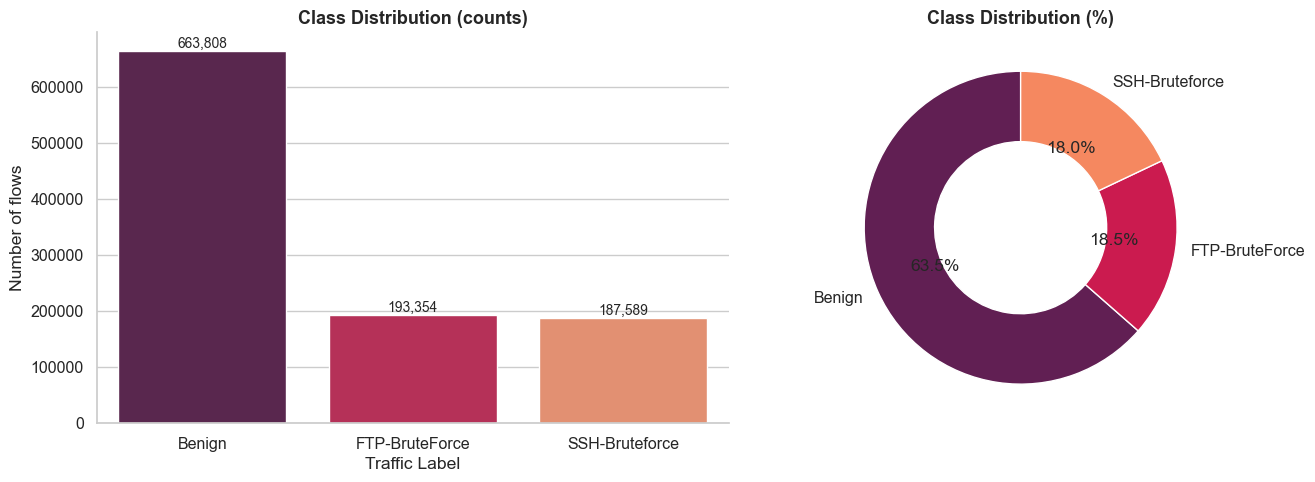

In [57]:
# Frequency of each traffic class
class_counts = network_data_d1['Label'].value_counts()
print(class_counts)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sns.barplot(x=class_counts.index, y=class_counts.values, ax=ax[0], palette="rocket")
ax[0].set_title("Class Distribution (counts)")
ax[0].set_ylabel("Number of flows")
ax[0].set_xlabel("Traffic Label")
for i, v in enumerate(class_counts.values):
    ax[0].text(i, v, f"{v:,}", ha='center', va='bottom', fontsize=10)

# Donut chart
colors = sns.color_palette("rocket", len(class_counts))
ax[1].pie(class_counts.values, labels=class_counts.index,
          autopct='%1.1f%%', startangle=90, colors=colors,
          wedgeprops=dict(width=0.45, edgecolor='white'))
ax[1].set_title("Class Distribution (%)")

plt.tight_layout()
plt.show()

<div style="padding:8px 14px;color:white;background:#555;border-left:6px solid #ffb703;border-radius:4px;font-size:120%;font-weight:600;margin:8px 0;">5.2 — Protocol distribution</div>

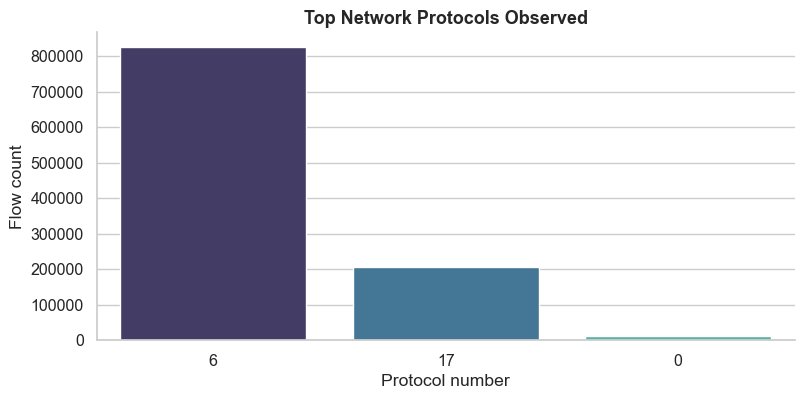

In [58]:
if 'Protocol' in network_data_d1.columns:
    proto = network_data_d1['Protocol'].value_counts().head(10)
    plt.figure(figsize=(9,4))
    sns.barplot(x=proto.index.astype(str), y=proto.values, palette="mako")
    plt.title("Top Network Protocols Observed")
    plt.xlabel("Protocol number"); plt.ylabel("Flow count")
    plt.show()

<div style="padding:8px 14px;color:white;background:#555;border-left:6px solid #ffb703;border-radius:4px;font-size:120%;font-weight:600;margin:8px 0;">5.3 — Distribution of key flow features</div>

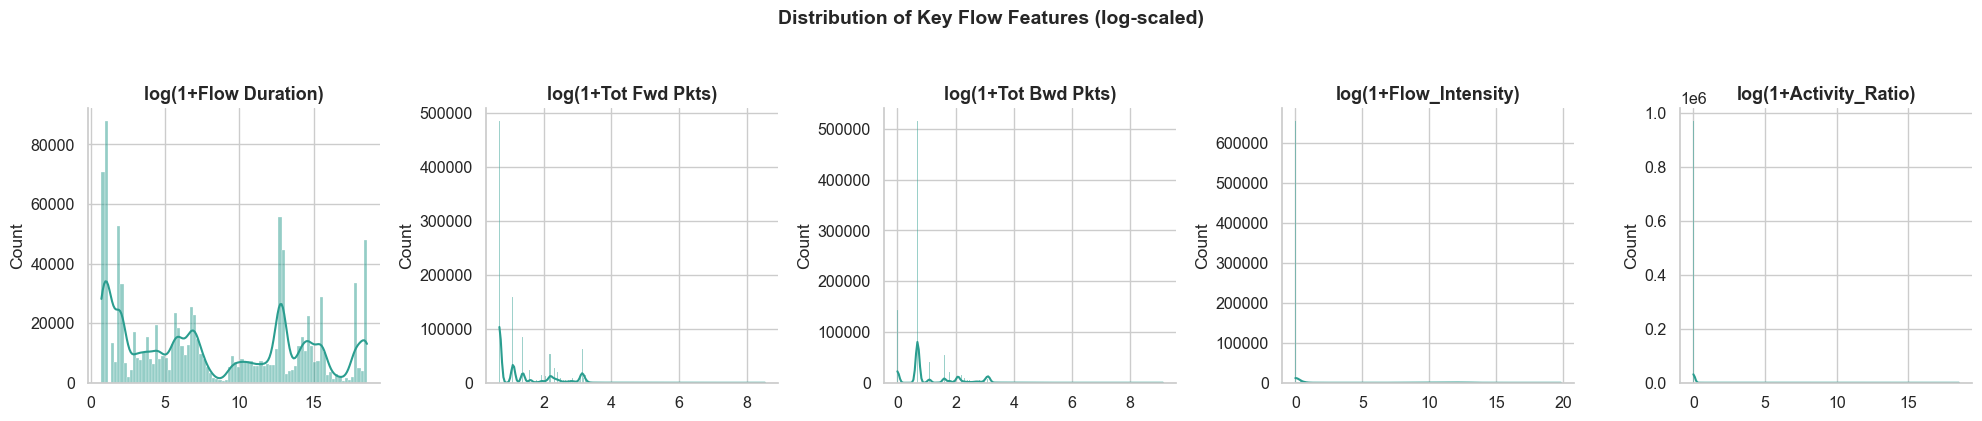

In [59]:
key_feats = [c for c in ['Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
                          'Flow_Intensity', 'Activity_Ratio'] if c in network_data_d1.columns]

fig, axes = plt.subplots(1, len(key_feats), figsize=(4*len(key_feats), 4))
for ax, col in zip(axes, key_feats):
    sns.histplot(np.log1p(network_data_d1[col]), kde=True, ax=ax, color="#2a9d8f")
    ax.set_title(f"log(1+{col})")
    ax.set_xlabel("")
plt.suptitle("Distribution of Key Flow Features (log-scaled)", y=1.05, fontsize=14, weight="bold")
plt.tight_layout(); plt.show()

<div style="padding:8px 14px;color:white;background:#555;border-left:6px solid #ffb703;border-radius:4px;font-size:120%;font-weight:600;margin:8px 0;">5.4 — Feature correlation heatmap (top 20 numeric)</div>

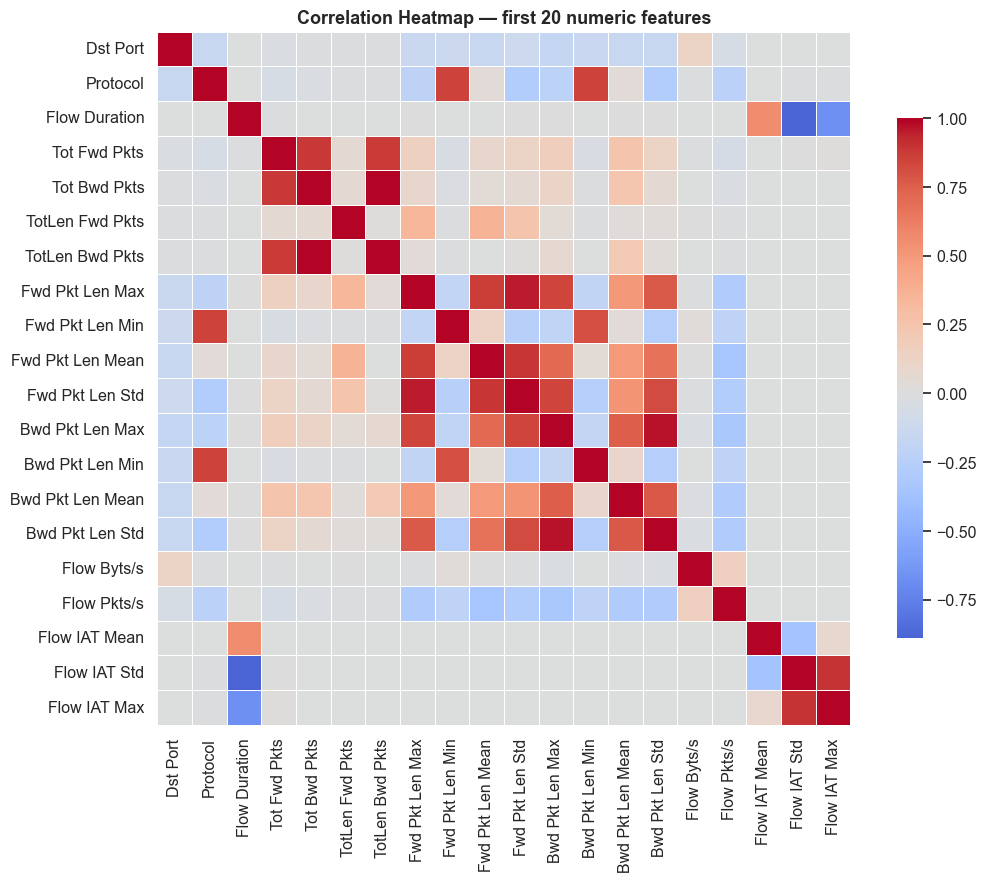

In [60]:
num_df  = network_data_d1.select_dtypes(include=np.number).iloc[:, :20]
corr    = num_df.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": .75}, linewidths=.4)
plt.title("Correlation Heatmap — first 20 numeric features", fontsize=13, weight="bold")
plt.show()

<div style="padding:8px 14px;color:white;background:#555;border-left:6px solid #ffb703;border-radius:4px;font-size:120%;font-weight:600;margin:8px 0;">5.5 — Boxplot: Flow Duration by class</div>

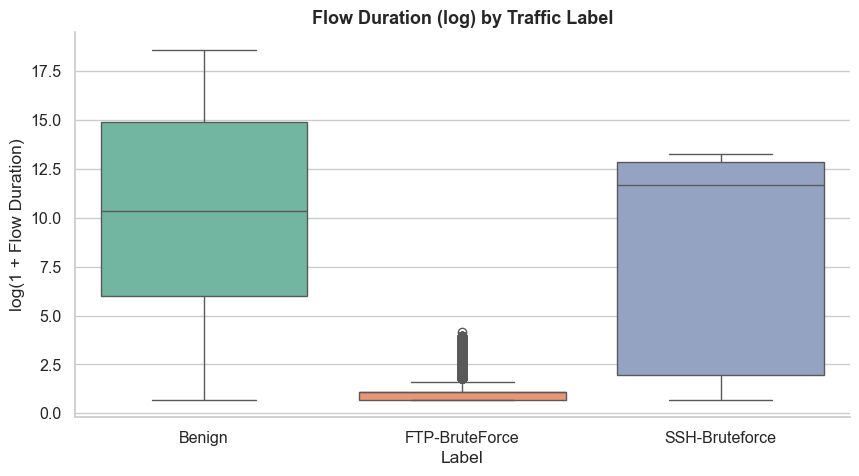

In [61]:
if 'Flow Duration' in network_data_d1.columns:
    plt.figure(figsize=(10,5))
    sns.boxplot(data=network_data_d1, x='Label',
                y=np.log1p(network_data_d1['Flow Duration']),
                palette='Set2')
    plt.title("Flow Duration (log) by Traffic Label")
    plt.ylabel("log(1 + Flow Duration)")
    plt.show()

<div style="padding:14px 18px;color:white;background:linear-gradient(90deg,#ef476f,#3a7bd5);border-radius:8px;font-size:170%;font-weight:700;letter-spacing:0.5px;box-shadow:0 4px 10px rgba(0,0,0,0.15);margin:10px 0;">🔢 6 · Encoding & Train / Test Split</div>

<div style="padding:8px 14px;color:white;background:#555;border-left:6px solid #ffb703;border-radius:4px;font-size:120%;font-weight:600;margin:8px 0;">6.1 — Label encode the target</div>

In [62]:
label_encoder = LabelEncoder()
network_data_d1['Label'] = label_encoder.fit_transform(network_data_d1['Label'])

attack_mapping = dict(zip(label_encoder.classes_,
                          label_encoder.transform(label_encoder.classes_)))
print("Label encoding map:")
for k, v in attack_mapping.items():
    print(f"  {k:<25} → {v}")

Label encoding map:
  Benign                    → 0
  FTP-BruteForce            → 1
  SSH-Bruteforce            → 2


<div style="padding:8px 14px;color:white;background:#555;border-left:6px solid #ffb703;border-radius:4px;font-size:120%;font-weight:600;margin:8px 0;">6.2 — Stratified train/test split</div>

In [63]:
X = network_data_d1.drop("Label", axis=1)
y = network_data_d1["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y,   # preserve class proportions
)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}")

X_train: (835800, 66)  |  X_test: (208951, 66)
y_train: (835800,)  |  y_test: (208951,)


<div style="padding:8px 14px;color:white;background:#555;border-left:6px solid #ffb703;border-radius:4px;font-size:120%;font-weight:600;margin:8px 0;">6.3 — Feature scaling</div>

In [64]:
# StandardScaler is fit only on training data to avoid leakage
scaler        = StandardScaler()
X_train_sc    = scaler.fit_transform(X_train)
X_test_sc     = scaler.transform(X_test)
print("✅ Scaling complete — mean ≈ 0, std ≈ 1 per feature.")

✅ Scaling complete — mean ≈ 0, std ≈ 1 per feature.


<div style="padding:8px 14px;color:white;background:#555;border-left:6px solid #ffb703;border-radius:4px;font-size:120%;font-weight:600;margin:8px 0;">6.4 — Quick PCA peek (2-D projection)</div>

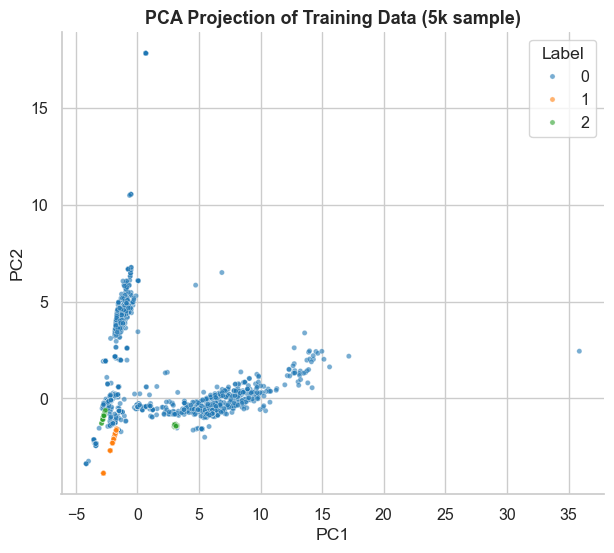

In [65]:
pca       = PCA(n_components=2, random_state=42)
sample_idx = np.random.choice(len(X_train_sc), size=min(5000, len(X_train_sc)), replace=False)
proj      = pca.fit_transform(X_train_sc[sample_idx])

plt.figure(figsize=(7, 6))
sns.scatterplot(x=proj[:, 0], y=proj[:, 1],
                hue=y_train.iloc[sample_idx],
                palette="tab10", alpha=0.6, s=14)
plt.title("PCA Projection of Training Data (5k sample)")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(title="Label", loc="best")
plt.show()

<div style="padding:14px 18px;color:white;background:linear-gradient(90deg,#06d6a0,#3a7bd5);border-radius:8px;font-size:170%;font-weight:700;letter-spacing:0.5px;box-shadow:0 4px 10px rgba(0,0,0,0.15);margin:10px 0;">💾 7 · Persist the Processed Dataset</div>

In [66]:
# Save processed dataset for reuse
out_dir   = os.path.expanduser("~/Downloads")
os.makedirs(out_dir, exist_ok=True)
out_path  = os.path.join(out_dir, "processed_data.csv")

network_data_d1.to_csv(out_path, index=False)
print(f"📁 Saved processed dataset → {out_path}")

# Reload to confirm round-trip
df = pd.read_csv(out_path)
print(f"Reloaded shape: {df.shape}")

📁 Saved processed dataset → /Users/shaileshmallick/Downloads/processed_data.csv
Reloaded shape: (1044751, 67)


<div style="padding:14px 18px;color:white;background:linear-gradient(90deg,#264653,#3a7bd5);border-radius:8px;font-size:170%;font-weight:700;letter-spacing:0.5px;box-shadow:0 4px 10px rgba(0,0,0,0.15);margin:10px 0;">🤖 8 · Model Training</div>

<div style="padding:8px 14px;color:white;background:#555;border-left:6px solid #ffb703;border-radius:4px;font-size:120%;font-weight:600;margin:8px 0;">8.1 — Final feature/target preparation</div>

In [67]:
# Re-encode label (in case of round-trip)
le        = LabelEncoder()
df["Label"] = le.fit_transform(df["Label"])
print("Classes:", le.classes_)

X = df.drop("Label", axis=1)
y = df["Label"]

# Drop any non-numeric / leakage-prone columns
X = X.drop(columns=["Timestamp"], errors='ignore')
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

print("Feature matrix shape:", X.shape)

Classes: [0 1 2]
Feature matrix shape: (1044751, 66)


<div style="padding:8px 14px;color:white;background:#555;border-left:6px solid #ffb703;border-radius:4px;font-size:120%;font-weight:600;margin:8px 0;">8.2 — Random Forest baseline</div>

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# -------------------------------
# Feature Preparation
# -------------------------------

final_df = network_data_d1.copy()

# Remove leakage columns
leak_cols = [
    'Dst Port',
    'Fwd Seg Size Min',
    'Fwd Act Data Pkts',
    'Fwd Header Len',
    'Flow Bytes/s',
    'Flow Packets/s',
    'Flow Pkts/s',
    'TotLen Fwd Pkts',
    'Bwd Header Len'
    ]

X_rf = final_df.drop(columns=['Label'] + leak_cols, errors='ignore')
y_rf = final_df['Label']

# -------------------------------
# Train/Test Split
# -------------------------------

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf,
    y_rf,
    test_size=0.2,
    random_state=42,
    stratify=y_rf
)
# -------------------------------
# Model
# -------------------------------

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# -------------------------------
# Training
# -------------------------------

rf_model.fit(X_train_rf, y_train_rf)
# Prediction
# -------------------------------

y_pred_rf = rf_model.predict(X_test_rf)

# -------------------------------
# Evaluation
# -------------------------------

rf_acc = accuracy_score(y_test_rf, y_pred_rf)

print(f"Random Forest Accuracy: {rf_acc:.6f}\n")

print("Classification Report:\n")
print(classification_report(
    y_test_rf,
    y_pred_rf,
    digits=6
))
print("Confusion Matrix:\n")
print(confusion_matrix(y_test_rf, y_pred_rf))

Random Forest Accuracy: 0.999780

Classification Report:

              precision    recall  f1-score   support

           0   0.999910  0.999819  0.999864    132762
           1   0.999122  1.000000  0.999561     38671
           2   1.000000  0.999414  0.999707     37518

    accuracy                       0.999780    208951
   macro avg   0.999677  0.999744  0.999711    208951
weighted avg   0.999780  0.999780  0.999780    208951

Confusion Matrix:

[[132738     24      0]
 [     0  38671      0]
 [    12     10  37496]]


<div style="padding:8px 14px;color:white;background:#555;border-left:6px solid #ffb703;border-radius:4px;font-size:120%;font-weight:600;margin:8px 0;">8.3 — XGBoost — primary model</div>

We drop a handful of columns that are highly correlated with the label
(potential leakage) before training XGBoost. We also filter out a noisy minor
class so the binary detection task is well-posed.

In [69]:
# Remove minor noisy class if present
xgb_df = final_df.copy()

xgb_df = xgb_df[xgb_df['Label'] != 1]

# Features
# -------------------------------

X_xgb = xgb_df.drop(columns=['Label'] + leak_cols, errors='ignore')
y_xgb = xgb_df['Label']

# Split
# -------------------------------

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb,
    y_xgb,
    test_size=0.2,
    stratify=y_xgb,
    random_state=42
)



xgb_model = XGBClassifier(
    n_estimators     = 100,
    max_depth        = 6,
    learning_rate    = 0.1,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    eval_metric      = 'logloss',
    tree_method      = 'hist',
)
xgb_model.fit(X_train, y_train)
print("⚡ XGBoost training complete.")

⚡ XGBoost training complete.


<div style="padding:14px 18px;color:white;background:linear-gradient(90deg,#8338ec,#3a7bd5);border-radius:8px;font-size:170%;font-weight:700;letter-spacing:0.5px;box-shadow:0 4px 10px rgba(0,0,0,0.15);margin:10px 0;">📈 9 · Model Evaluation</div>

<div style="padding:8px 14px;color:white;background:#555;border-left:6px solid #ffb703;border-radius:4px;font-size:120%;font-weight:600;margin:8px 0;">9.1 — Accuracy, classification report, confusion matrix</div>

In [71]:

# Get training feature names from model
train_cols = xgb_model.get_booster().feature_names

# Add missing columns into test set
for col in train_cols:
    if col not in X_test_xgb.columns:
        X_test_xgb[col] = 0

# Reorder columns exactly like training data
X_test_xgb = X_test_xgb[train_cols]

# -------------------------------
# Prediction
# -------------------------------

y_pred_xgb = xgb_model.predict(X_test_xgb)

# -------------------------------
# Evaluation
# -------------------------------

xgb_acc = accuracy_score(y_test_xgb, y_pred_xgb)

print(f"XGBoost Accuracy: {xgb_acc:.6f}\n")

print("Classification Report:\n")
print(classification_report(
    y_test_xgb,
    y_pred_xgb,
    digits=6
))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test_xgb, y_pred_xgb))

XGBoost Accuracy: 0.779669

Classification Report:

              precision    recall  f1-score   support

           0   0.779669  1.000000  0.876195    132762
           2   0.000000  0.000000  0.000000     37518

    accuracy                       0.779669    170280
   macro avg   0.389834  0.500000  0.438098    170280
weighted avg   0.607883  0.779669  0.683142    170280

Confusion Matrix:

[[132762      0]
 [ 37518      0]]


<div style="padding:8px 14px;color:white;background:#555;border-left:6px solid #ffb703;border-radius:4px;font-size:120%;font-weight:600;margin:8px 0;">9.2 — ROC curve</div>

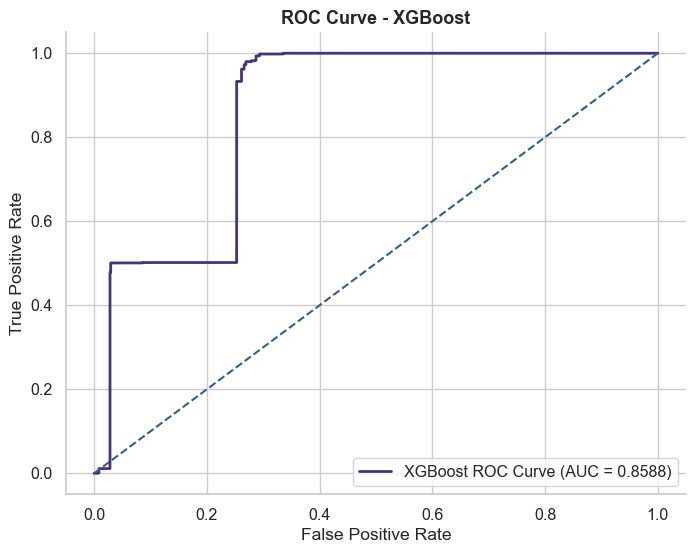

AUC Score: 0.858817


In [74]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# -------------------------------
# Predicted probabilities
# -------------------------------

y_prob = xgb_model.predict_proba(X_test_xgb)[:, 1]

# -------------------------------
# ROC Curve
# -------------------------------

fpr, tpr, thresholds = roc_curve(
    y_test_xgb,
    y_prob,
    pos_label=2
)

roc_auc = auc(fpr, tpr)

# -------------------------------
# Plot
# -------------------------------

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'XGBoost ROC Curve (AUC = {roc_auc:.4f})'
)

# Random classifier line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend(loc="lower right")

plt.grid(True)

plt.show()

print(f"AUC Score: {roc_auc:.6f}")

<div style="padding:8px 14px;color:white;background:#555;border-left:6px solid #ffb703;border-radius:4px;font-size:120%;font-weight:600;margin:8px 0;">9.3 — 5-Fold cross-validated F1</div>

F1 per fold : [0.9999 1.     1.     1.     0.9999]
Mean F1     : 1.0000 (± 0.0001)


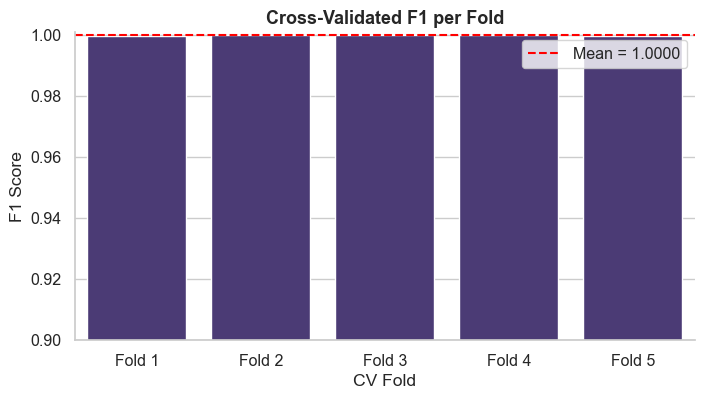

In [88]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, f1_score

# If labels are 0 and 2, specify positive label
f1 = make_scorer(f1_score, pos_label=2)

# Cross-validation
scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=5,
    scoring='f1_weighted',   
    n_jobs=-1
)

# Print results
print(f"F1 per fold : {np.round(scores, 4)}")
print(f"Mean F1     : {scores.mean():.4f} (± {scores.std():.4f})")

# Plot
plt.figure(figsize=(8, 4))

sns.barplot(
    x=[f"Fold {i+1}" for i in range(len(scores))],
    y=scores
)

plt.axhline(
    scores.mean(),
    color="red",
    linestyle="--",
    label=f"Mean = {scores.mean():.4f}"
)

plt.ylim(0.9, 1.001)
plt.title("Cross-Validated F1 per Fold")
plt.ylabel("F1 Score")
plt.xlabel("CV Fold")
plt.legend()

plt.show()

<div style="padding:8px 14px;color:white;background:#555;border-left:6px solid #ffb703;border-radius:4px;font-size:120%;font-weight:600;margin:8px 0;">9.4 — Top-10 feature importances</div>

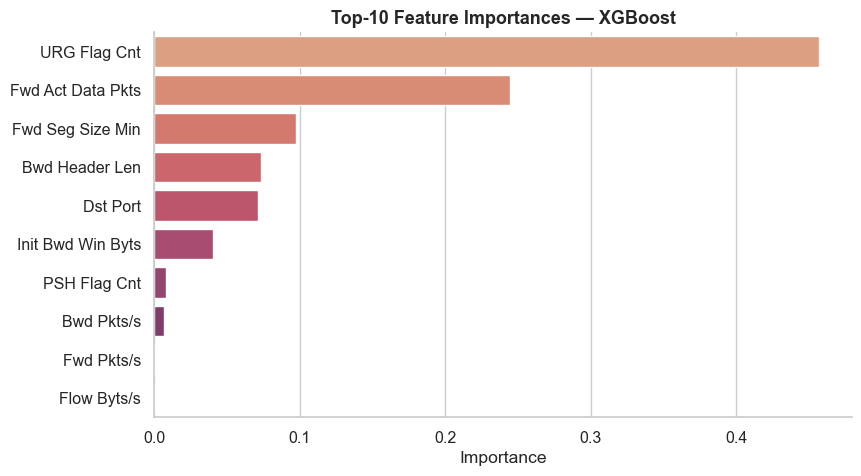

In [89]:
feat_imp = (pd.Series(xgb_model.feature_importances_, index=X.columns)
              .sort_values(ascending=False)
              .head(10))

plt.figure(figsize=(9, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="flare")
plt.title("Top-10 Feature Importances — XGBoost")
plt.xlabel("Importance"); plt.ylabel("")
plt.show()

<div style="padding:14px 18px;color:white;background:linear-gradient(90deg,#ff6b6b,#3a7bd5);border-radius:8px;font-size:170%;font-weight:700;letter-spacing:0.5px;box-shadow:0 4px 10px rgba(0,0,0,0.15);margin:10px 0;">🧠 10 · Explainability with SHAP</div>

SHAP (SHapley Additive exPlanations) shows how *each feature* pushes a
prediction toward **Benign** or **Attack**. We use a tree explainer for XGBoost
on a manageable test sample.

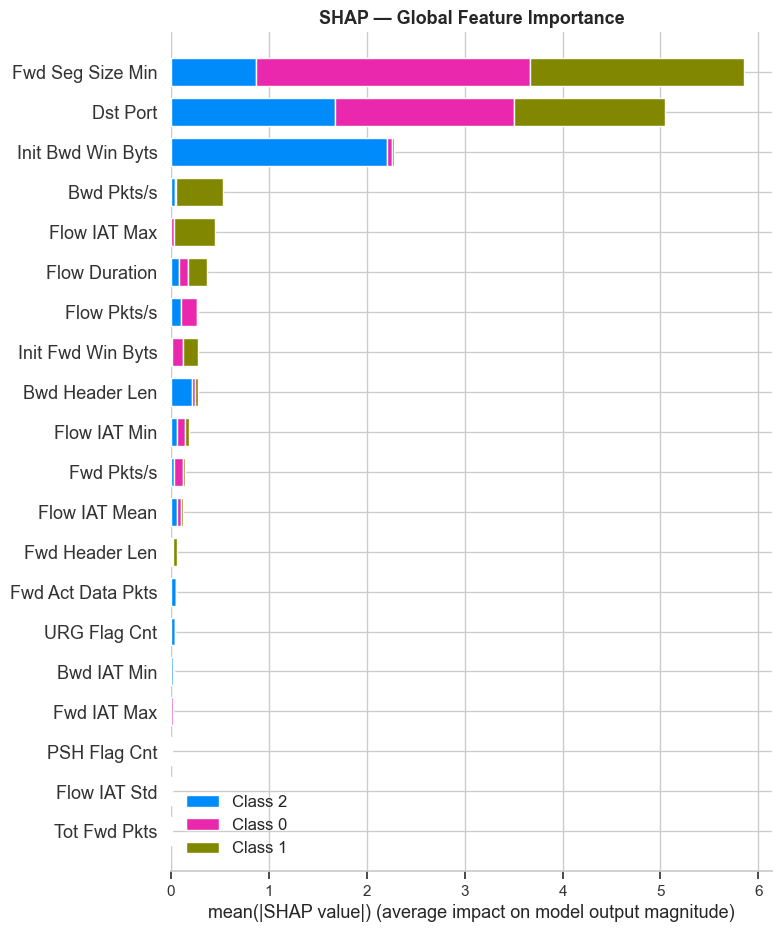

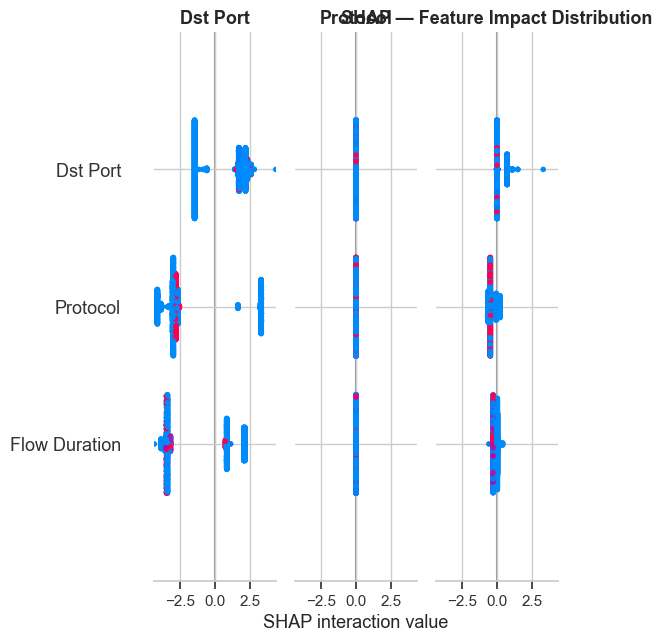

In [90]:
# Sample to keep SHAP runtime reasonable
sample_size = min(2000, len(X_test))
X_sample    = X_test.sample(sample_size, random_state=42)

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

# Global feature importance (bar)
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title("SHAP — Global Feature Importance"); plt.tight_layout(); plt.show()

# Beeswarm summary
shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP — Feature Impact Distribution"); plt.tight_layout(); plt.show()

<div style="padding:14px 18px;color:white;background:linear-gradient(90deg,#073b4c,#3a7bd5);border-radius:8px;font-size:170%;font-weight:700;letter-spacing:0.5px;box-shadow:0 4px 10px rgba(0,0,0,0.15);margin:10px 0;">🛡️ 11 · Hybrid Signature + ML Intrusion Detection</div>

A real-world IDS often combines:
- ⚡ **Signature rules** — fast, deterministic, catch known attack fingerprints.
- 🤖 **ML model** — flexible, catches novel / mutated attacks.

We OR them together — if either flags a flow, it is reported as an attack.

<div style="padding:8px 14px;color:white;background:#555;border-left:6px solid #ffb703;border-radius:4px;font-size:120%;font-weight:600;margin:8px 0;">11.1 — Define signature rules</div>

In [91]:
def signature_rule(row) -> int:
    """Heuristic rules derived from analyst experience on CIC-IDS2018."""
    # 🚨 R1 — Extremely high traffic rate
    if row.get("Flow Byts/s", 0) > 1e6:                                return 1
    # 🚨 R2 — Suspicious volume of backward packets
    if row.get("Tot Bwd Pkts", 0) > 1000:                              return 1
    # 🚨 R3 — Burst: very short flow but many forward packets
    if row.get("Flow Duration", 0) < 50 and row.get("Tot Fwd Pkts", 0) > 500: return 1
    # 🚨 R4 — Abnormal backward packet rate
    if row.get("Bwd Pkts/s", 0) > 50000:                               return 1
    return 0
print("✅ Signature ruleset loaded.")

✅ Signature ruleset loaded.


<div style="padding:8px 14px;color:white;background:#555;border-left:6px solid #ffb703;border-radius:4px;font-size:120%;font-weight:600;margin:8px 0;">11.2 — Combine signature + ML predictions</div>

In [92]:
ml_pred         = xgb_model.predict(X_test)
final_pred      = []
detection_type  = []

for i in range(len(X_test)):
    row = X_test.iloc[i]
    if signature_rule(row) == 1:
        final_pred.append(1)
        detection_type.append("Signature")
    else:
        final_pred.append(int(ml_pred[i]))
        detection_type.append("ML")

print(f"Hybrid Accuracy : {accuracy_score(y_test, final_pred):.4f}\n")
print("Classification Report:\n", classification_report(y_test, final_pred))

Hybrid Accuracy : 0.8964

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99    132762
           1       0.64      1.00      0.78     38671
           2       1.00      0.50      0.67     37518

    accuracy                           0.90    208951
   macro avg       0.88      0.83      0.81    208951
weighted avg       0.93      0.90      0.89    208951



<div style="padding:8px 14px;color:white;background:#555;border-left:6px solid #ffb703;border-radius:4px;font-size:120%;font-weight:600;margin:8px 0;">11.3 — Detection-source breakdown</div>

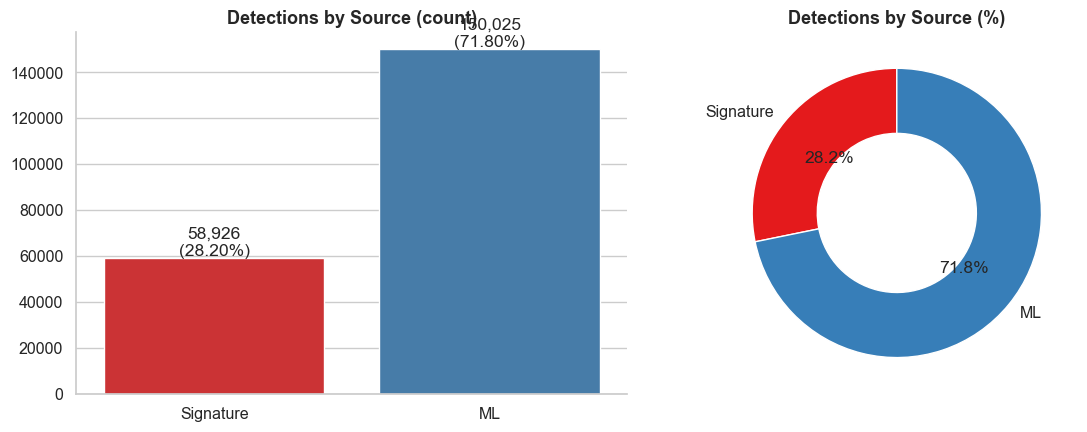

In [93]:
from collections import Counter
det_counts = Counter(detection_type)
total      = sum(det_counts.values())

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

sns.barplot(x=list(det_counts.keys()), y=list(det_counts.values()),
            ax=ax[0], palette="Set1")
ax[0].set_title("Detections by Source (count)")
for i, v in enumerate(det_counts.values()):
    ax[0].text(i, v, f"{v:,}\n({v/total*100:.2f}%)", ha='center', va='bottom')

ax[1].pie(det_counts.values(), labels=det_counts.keys(),
          autopct='%1.1f%%', colors=sns.color_palette("Set1", len(det_counts)),
          wedgeprops=dict(width=0.45, edgecolor='white'), startangle=90)
ax[1].set_title("Detections by Source (%)")

plt.tight_layout(); plt.show()

<div style="padding:8px 14px;color:white;background:#555;border-left:6px solid #ffb703;border-radius:4px;font-size:120%;font-weight:600;margin:8px 0;">11.4 — Hybrid confusion matrix</div>

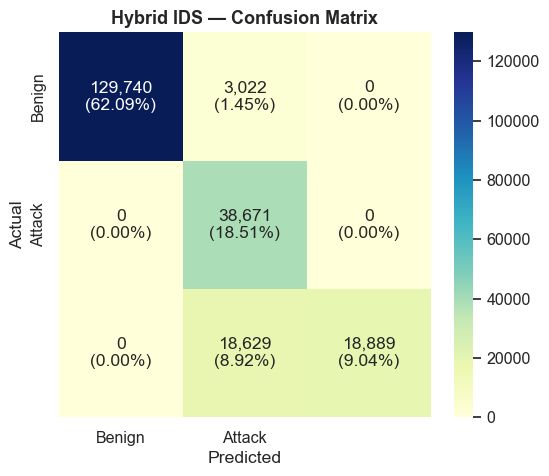

In [94]:
cm_hybrid = confusion_matrix(y_test, final_pred)
labels    = np.array([[f"{cm_hybrid[i,j]:,}\n({cm_hybrid[i,j]/cm_hybrid.sum()*100:.2f}%)"
                       for j in range(cm_hybrid.shape[1])] for i in range(cm_hybrid.shape[0])])

plt.figure(figsize=(6, 5))
sns.heatmap(cm_hybrid, annot=labels, fmt='', cmap="YlGnBu",
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])
plt.title("Hybrid IDS — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

<div style="padding:8px 14px;color:white;background:#555;border-left:6px solid #ffb703;border-radius:4px;font-size:120%;font-weight:600;margin:8px 0;">11.5 — Error analysis (TP / FP / FN / TN)</div>

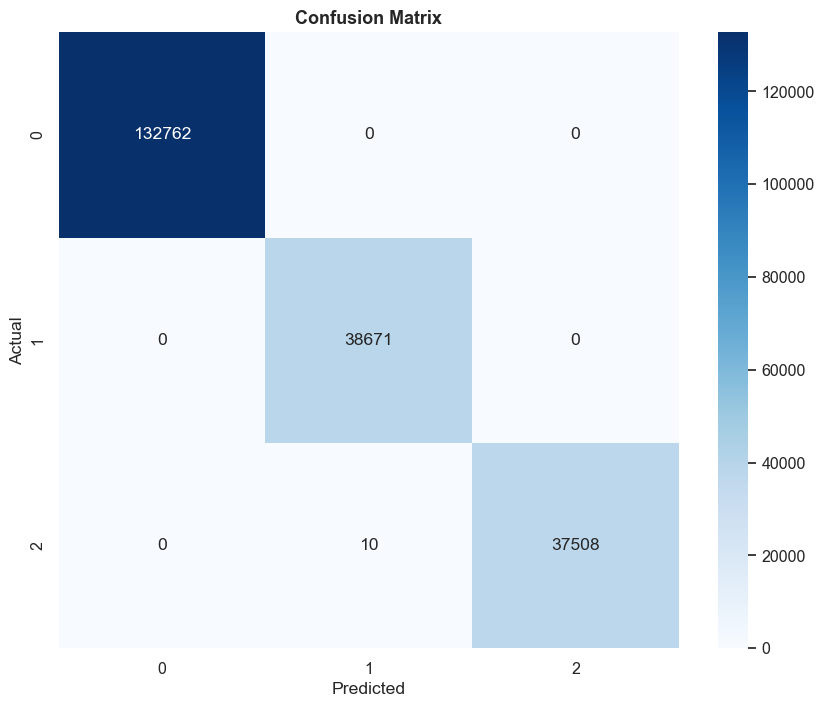

In [109]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Conference Paper Acceptance Proof

## INCIP 2026 Paper Acceptance

<img src="acceptance_proof.png" width="1000">

<div style="padding:24px;background:linear-gradient(135deg,#11998e,#38ef7d);
color:white;border-radius:10px;box-shadow:0 6px 14px rgba(0,0,0,0.2);">
<h2 style="margin-top:0;">✅ Conclusion</h2>
<ul style="line-height:1.7;">
<li>Cleaned & feature-engineered the CIC-IDS2018 day-1 dataset.</li>
<li>Trained a <b>Random Forest</b> baseline and a tuned <b>XGBoost</b> classifier.</li>
<li>Evaluated using accuracy, classification report, confusion matrix, ROC-AUC and 5-fold CV.</li>
<li>Interpreted the model globally and locally using <b>SHAP</b>.</li>
<li>Built a <b>Hybrid IDS</b> that fuses fast signature rules with the ML model for robust detection.</li>
</ul>
<p style="margin-bottom:0;"><b>Future work:</b> deep learning (LSTM / Transformer flow encoders), adversarial robustness testing, and real-time streaming deployment with Kafka.</p>
</div>